# UNLOCKD Risk Simulation (Monte Carlo)

This notebook runs GBM-based simulations to estimate conservative PV percentiles
for locked tokens. Use it to calibrate governance parameters and stress test
asset classes.

Assumptions and limits:
- GBM with constant drift/volatility (no jumps or mean reversion)
- Continuous compounding; months are converted to years
- Results are per-token (P0) times quantity (Q) in base currency units


In [1]:
import numpy as np
import pandas as pd

config = {
    "P0": 10.0,
    "Q": 1000.0,
    "r": 0.05,
    "vols": [0.30, 0.50, 0.70],
    "months": list(range(0, 37, 3)),
    "paths": 10_000,
    "seed": 42,
    "percentiles": [1, 5, 10],
    "model": "gbm",  # "gbm" | "jump" | "mean_reversion"
    "model_params": {
        "jump_lambda": 0.30,
        "jump_mu": -0.02,
        "jump_sigma": 0.15,
        "kappa": 1.50,
        "theta": None,
    },
    "policy_percentile": 5,
    "policy_ltv_bps": 3500,
    "interest_bps": 600,
    "coverage_target": 1.10,
    "output_dir": "output",
}

P0 = config["P0"]
Q = config["Q"]
r = config["r"]
vols = config["vols"]
months = config["months"]
paths = config["paths"]
seed_base = config["seed"]
percentiles = config["percentiles"]
model = config["model"]
model_params = config["model_params"]
policy_percentile = config["policy_percentile"]
policy_ltv_bps = config["policy_ltv_bps"]
interest_bps = config["interest_bps"]
coverage_target = config["coverage_target"]
output_dir = config["output_dir"]

In [2]:
def simulate_grid(
    P0,
    Q,
    r,
    vols,
    months,
    n_paths,
    percentiles,
    model,
    params,
    seed,
    return_pv=False,
):
    months_arr = np.array(months, dtype=float)
    vols_arr = np.array(vols, dtype=float)
    t = months_arr / 12.0

    rng = np.random.default_rng(seed)
    z = rng.standard_normal(size=(t.size, vols_arr.size, n_paths))

    if model == "gbm":
        drift = (r - 0.5 * vols_arr ** 2)[None, :, None] * t[:, None, None]
        diffusion = vols_arr[None, :, None] * np.sqrt(t)[:, None, None] * z
        pt = P0 * np.exp(drift + diffusion)
    elif model == "jump":
        jump_lambda = params.get("jump_lambda", 0.30)
        jump_mu = params.get("jump_mu", -0.02)
        jump_sigma = params.get("jump_sigma", 0.15)
        z_jump = rng.standard_normal(size=(t.size, vols_arr.size, n_paths))
        n_jumps = rng.poisson(lam=t[:, None, None] * jump_lambda, size=z.shape)
        jump = n_jumps * jump_mu + np.sqrt(n_jumps) * jump_sigma * z_jump
        k = np.exp(jump_mu + 0.5 * jump_sigma ** 2) - 1.0
        drift = (r - 0.5 * vols_arr ** 2 - jump_lambda * k)[None, :, None] * t[:, None, None]
        diffusion = vols_arr[None, :, None] * np.sqrt(t)[:, None, None] * z
        pt = P0 * np.exp(drift + diffusion + jump)
    elif model == "mean_reversion":
        kappa = params.get("kappa", 1.50)
        theta = params.get("theta", None)
        if theta is None:
            theta = np.log(P0)
        x0 = np.log(P0)
        exp_term = np.exp(-kappa * t)
        mean_x = theta + (x0 - theta) * exp_term
        var_x = (vols_arr ** 2)[None, :, None] * (1.0 - np.exp(-2.0 * kappa * t))[:, None, None] / (2.0 * kappa)
        x = mean_x[:, None, None] + np.sqrt(var_x) * z
        pt = np.exp(x)
    else:
        raise ValueError(f"Unknown model: {model}")

    discount = np.exp(-r * t)[:, None, None]
    pv = discount * Q * pt

    mean_pv = pv.mean(axis=2)
    pct = {p: np.percentile(pv, p, axis=2) for p in percentiles}
    p5 = pct.get(5, np.percentile(pv, 5, axis=2))
    es5 = np.nanmean(np.where(pv <= p5[:, :, None], pv, np.nan), axis=2)

    return {
        "mean": mean_pv,
        "percentiles": pct,
        "es5": es5,
        "pv": pv if return_pv else None,
    }

In [3]:
grid = simulate_grid(
    P0,
    Q,
    r,
    vols,
    months,
    paths,
    percentiles,
    model,
    model_params,
    seed_base,
    return_pv=True,
)

interest_rate = interest_bps / 10000.0
policy_ltv = policy_ltv_bps / 10000.0

rows = []
for mi, m in enumerate(months):
    row = {"Months": m}
    for si, sigma in enumerate(vols):
        row[f"Vol {int(sigma*100)}% Mean PV"] = round(grid["mean"][mi, si], 0)
        for p in percentiles:
            row[f"Vol {int(sigma*100)}% P{p} PV"] = round(grid["percentiles"][p][mi, si], 0)
        row[f"Vol {int(sigma*100)}% ES5 PV"] = round(grid["es5"][mi, si], 0)

        policy_pv = grid["percentiles"][policy_percentile][mi, si]
        policy_borrow = policy_pv * policy_ltv
        policy_debt = policy_borrow * (1 + interest_rate)
        shortfall_prob = np.mean(grid["pv"][mi, si, :] < policy_debt)
        max_borrow_cov = policy_pv / coverage_target / (1 + interest_rate)

        row[f"Vol {int(sigma*100)}% Policy Borrow"] = round(policy_borrow, 0)
        row[f"Vol {int(sigma*100)}% Policy Debt"] = round(policy_debt, 0)
        row[f"Vol {int(sigma*100)}% Shortfall Prob"] = round(shortfall_prob, 4)
        row[f"Vol {int(sigma*100)}% Max Borrow @ Coverage"] = round(max_borrow_cov, 0)
    rows.append(row)

result = pd.DataFrame(rows)
result

,Months,Vol 30% Mean PV,Vol 30% P1 PV,Vol 30% P5 PV,Vol 30% P10 PV,Vol 30% ES5 PV,Vol 30% Policy Borrow,Vol 30% Policy Debt,Vol 30% Shortfall Prob,Vol 30% Max Borrow @ Coverage,...,Vol 50% Max Borrow @ Coverage,Vol 70% Mean PV,Vol 70% P1 PV,Vol 70% P5 PV,Vol 70% P10 PV,Vol 70% ES5 PV,Vol 70% Policy Borrow,Vol 70% Policy Debt,Vol 70% Shortfall Prob,Vol 70% Max Borrow @ Coverage
0,0,10000.0,10000.0,10000.0,10000.0,10000.0,3500.0,3710.0,0.0000,8576.0,...,8576.0,10000.0,10000.0,10000.0,10000.0,10000.0,3500.0,3710.0,0.0000,8576.0
1,3,9991.0,6961.0,7703.0,8128.0,7261.0,2696.0,2858.0,0.0000,6606.0,...,5502.0,9987.0,4126.0,5267.0,5999.0,4593.0,1844.0,1954.0,0.0000,4518.0
2,6,10016.0,5906.0,6881.0,7465.0,6303.0,2408.0,2553.0,0.0000,5901.0,...,4482.0,10013.0,2778.0,3802.0,4676.0,3179.0,1331.0,1411.0,0.0000,3261.0
3,9,9941.0,5306.0,6304.0,6856.0,5681.0,2206.0,2339.0,0.0000,5406.0,...,3829.0,10047.0,2044.0,3088.0,3823.0,2464.0,1081.0,1146.0,0.0003,2649.0
4,12,9993.0,4767.0,5877.0,6562.0,5173.0,2057.0,2180.0,0.0000,5040.0,...,3281.0,9958.0,1556.0,2450.0,3161.0,1899.0,857.0,909.0,0.0007,2101.0
5,15,10008.0,4317.0,5422.0,6159.0,4758.0,1898.0,2012.0,0.0000,4650.0,...,2986.0,10254.0,1207.0,2089.0,2759.0,1549.0,731.0,775.0,0.0019,1791.0
6,18,10003.0,4028.0,5049.0,5774.0,4395.0,1767.0,1873.0,0.0000,4330.0,...,2622.0,9912.0,929.0,1718.0,2335.0,1244.0,601.0,637.0,0.0032,1474.0
7,21,10032.0,3648.0,4815.0,5586.0,4114.0,1685.0,1786.0,0.0000,4129.0,...,2321.0,10035.0,804.0,1434.0,2003.0,1046.0,502.0,532.0,0.0027,1230.0
8,24,10017.0,3456.0,4544.0,5308.0,3864.0,1591.0,1686.0,0.0000,3897.0,...,2092.0,9985.0,592.0,1224.0,1750.0,847.0,428.0,454.0,0.0046,1050.0
9,27,10099.0,3237.0,4342.0,5132.0,3698.0,1520.0,1611.0,0.0000,3724.0,...,1904.0,9952.0,514.0,1038.0,1516.0,721.0,363.0,385.0,0.0040,890.0


In [4]:
# LTV curve + borrow limits derived from conservative percentile PV

def ltv_for_months(month):
    return max(0.25, 0.40 - (0.15 / 36.0) * month)

ltv = result["Months"].apply(ltv_for_months)

borrow_rows = pd.DataFrame({
    "Months": result["Months"],
    "LTV %": (ltv * 100).round(2),
    "Borrow 30%": (result[f"Vol 30% P{policy_percentile} PV"] * ltv).round(0),
    "Borrow 50%": (result[f"Vol 50% P{policy_percentile} PV"] * ltv).round(0),
    "Borrow 70%": (result[f"Vol 70% P{policy_percentile} PV"] * ltv).round(0),
})

borrow_rows

,Months,LTV %,Borrow 30%,Borrow 50%,Borrow 70%
0,0,40.00,4000.0,4000.0,4000.0
1,3,38.75,2985.0,2486.0,2041.0
2,6,37.50,2580.0,1960.0,1426.0
3,9,36.25,2285.0,1619.0,1119.0
4,12,35.00,2057.0,1339.0,858.0
5,15,33.75,1830.0,1175.0,705.0
6,18,32.50,1641.0,994.0,558.0
7,21,31.25,1505.0,846.0,448.0
8,24,30.00,1363.0,732.0,367.0
9,27,28.75,1248.0,638.0,298.0


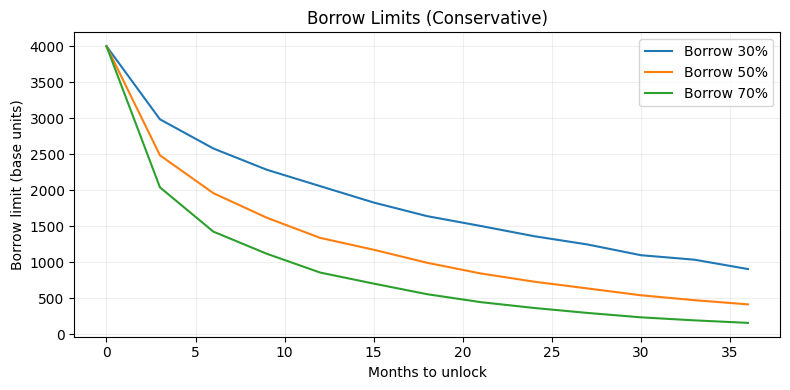

In [5]:
# Plot borrow limits (conservative percentile PV × LTV)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(borrow_rows["Months"], borrow_rows["Borrow 30%"], label="Borrow 30%")
ax.plot(borrow_rows["Months"], borrow_rows["Borrow 50%"], label="Borrow 50%")
ax.plot(borrow_rows["Months"], borrow_rows["Borrow 70%"], label="Borrow 70%")

ax.set_title("Borrow Limits (Conservative)")
ax.set_xlabel("Months to unlock")
ax.set_ylabel("Borrow limit (base units)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [6]:
# Export results to CSV for governance reviews
from pathlib import Path
import json

output_dir = Path(output_dir)
if not output_dir.is_absolute():
    output_dir = Path.cwd() / output_dir
output_dir.mkdir(parents=True, exist_ok=True)
results_path = output_dir / "risk_sim_results.csv"
borrow_path = output_dir / "risk_sim_borrow_limits.csv"
meta_path = output_dir / "risk_sim_metadata.json"

result.to_csv(results_path, index=False)
borrow_rows.to_csv(borrow_path, index=False)

metadata = {
    "config": config,
    "model": model,
    "model_params": model_params,
    "generated_at": pd.Timestamp.utcnow().isoformat() + "Z",
}
meta_path.write_text(json.dumps(metadata, indent=2))

results_path, borrow_path, meta_path

(PosixPath('/Users/mac/Protocol/UNLOCKD/notebooks/output/risk_sim_results.csv'),
 PosixPath('/Users/mac/Protocol/UNLOCKD/notebooks/output/risk_sim_borrow_limits.csv'),
 PosixPath('/Users/mac/Protocol/UNLOCKD/notebooks/output/risk_sim_metadata.json'))

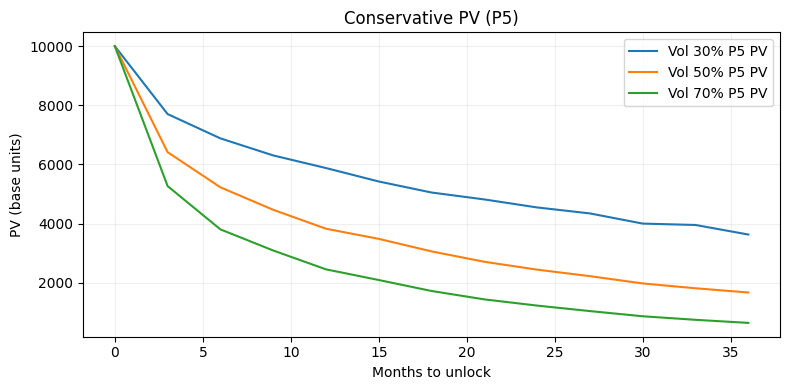

In [7]:
# Plot 5th percentile PV by months for each volatility band
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
for sigma in vols:
    column = f"Vol {int(sigma * 100)}% P{policy_percentile} PV"
    ax.plot(result["Months"], result[column], label=column)

ax.set_title(f"Conservative PV (P{policy_percentile})")
ax.set_xlabel("Months to unlock")
ax.set_ylabel("PV (base units)")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()